# Movies Example - Predicing the "NaN"-values

Author: Andreas Traut

In this example I used a dataset which contains the following columns: 

 Rank | Title | Year | Score | Metascore | Genre | Vote | Director | Runtime | **Revenue** | Description | RevCat

My aim was to predict the **Revenue** based on the other information. There are some "NaN"-values in the column "Revenue" and I wanted to predict these values. 

# Importing the data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder  #we will need this later
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

In [2]:
PATH = os.path.join("datasets", "movies")

def format_plot(ax, title, feature1, feature2):
    #ax.xaxis.set_major_formatter(plt.NullFormatter())
    #ax.yaxis.set_major_formatter(plt.NullFormatter())
    ax.set_xlabel(feature1, color='gray')
    ax.set_ylabel(feature2, color='gray')
    ax.set_title(title, color='gray')

The movies dataset can be found here: https://www.kaggle.com/isaactaylorofficial/imdb-10000-most-voted-feature-films-041118

In [3]:
def load_data(path=PATH):
    csv_path = os.path.join(path, "movies.csv")
    return pd.read_csv(csv_path)

movies_load = load_data()

In [4]:
movies_l = movies_load[movies_load['Year']<2000]
movies = movies_l[:].copy(deep=True)

In [5]:
movies['Jahrzehnt'] = (movies['Year']-1900 ) // 10
movies['Jahrzehnt'].value_counts()

9    1637
8     929
7     472
6     344
5     253
4     165
3     102
2      35
1       3
Name: Jahrzehnt, dtype: int64

# "NaN"-values in column "Revenue"

In column "Revenue" there are 7473 "non-null" values, and 2527 "null" values:

In [6]:
movies_RevenueNaN = movies[movies["Revenue"].isnull()]
len_movies_RevenueNaN = len(movies_RevenueNaN)
len_movies_RevenueNaN

1092

In [7]:
movies_NotNull = movies[movies["Revenue"].notnull()]
len_movies_NotNull = len(movies_NotNull)
len_movies_NotNull

2848

In [8]:
len_movies_RevenueNaN + len_movies_NotNull

3940

<function matplotlib.pyplot.show(*args, **kw)>

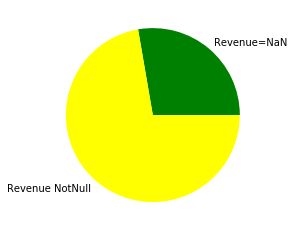

In [9]:
fig, axs = plt.subplots()
axs.pie([len_movies_RevenueNaN, len_movies_NotNull], 
        labels=['Revenue=NaN', 'Revenue NotNull'], 
        colors  = ['green', 'yellow']
       )
plt.show

# Visualisation of the data

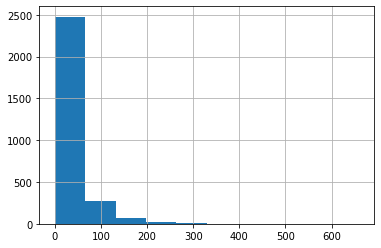

In [10]:
movies_NotNull['Revenue'].hist()

# Stratified Sampling

In [11]:
movies_NotNullC = movies_NotNull[:].copy(deep=True)

movies_NotNullC['RevCat']=pd.cut(movies_NotNullC['Revenue'], 
                        bins=[-1,100,200,300,np.inf], 
                        labels=[1, 2, 3, 4])
movies_NotNullC['RevCat'].value_counts()

1    2645
2     172
3      22
4       9
Name: RevCat, dtype: int64

In [12]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
for train_index, test_index in split.split(movies_NotNullC, movies_NotNullC["RevCat"]):
    strat_train_set = movies_NotNullC.iloc[train_index]
    strat_test_set = movies_NotNullC.iloc[test_index]

In [13]:
strat_test_set["RevCat"].value_counts() / len(strat_test_set)

1    0.929073
2    0.060393
3    0.007725
4    0.002809
Name: RevCat, dtype: float64

In [14]:
movies_NotNullC["RevCat"].value_counts() / len(movies_NotNullC)

1    0.928722
2    0.060393
3    0.007725
4    0.003160
Name: RevCat, dtype: float64

In [15]:
def revenue_cat_proportions(data):
    return data["RevCat"].value_counts() / len(data)

train_set, test_set = train_test_split(movies_NotNullC, test_size=0.9, random_state=42)

compare_props = pd.DataFrame({
    "Overall": revenue_cat_proportions(movies_NotNullC),
    "Stratified": revenue_cat_proportions(strat_test_set),
    "Random": revenue_cat_proportions(test_set),
}).sort_index()

compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

print(compare_props)

for set_ in (strat_train_set, strat_test_set):
    set_.drop("RevCat", axis=1, inplace=True)

    Overall  Stratified    Random  Rand. %error  Strat. %error
1  0.928722    0.929073  0.926287     -0.262173       0.037807
2  0.060393    0.060393  0.062012      2.681131       0.000000
3  0.007725    0.007725  0.008190      6.027514       0.000000
4  0.003160    0.002809  0.003510     11.076443     -11.111111


C:\Users\andre\Anaconda3\lib\site-packages\pandas\core\frame.py:3997: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [16]:
movies_train = strat_train_set.drop('Revenue', axis=1)
movies_train_labels = strat_train_set['Revenue'].copy()
len_movies_train = len(movies_train)
len_movies_train

1424

In [17]:
movies_test = strat_test_set.drop('Revenue', axis=1)
movies_test_labels = strat_test_set['Revenue'].copy()
len_movies_test = len(movies_test)
len_movies_test

1424

In [18]:
len_movies_train + len_movies_test

2848

In [19]:
len_movies_NotNull

2848

In [20]:
len_movies_RevenueNaN

1092

In [21]:
len_movies_train + len_movies_test + len_movies_RevenueNaN 

3940

The whole dataset of 10000 rows has been split up into 
- a training dataset ("movies_train"), 
- a testing dataset ("movies_test") and
- a dataset, where "Revenue"="NaN"

<function matplotlib.pyplot.show(*args, **kw)>

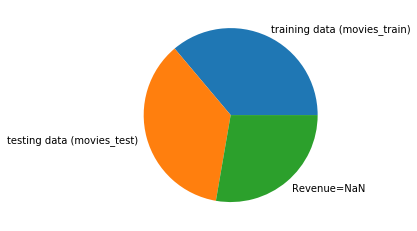

In [22]:
fracs = [len_movies_train, len_movies_test, len_movies_RevenueNaN]
labels = ['training data (movies_train)', 'testing data (movies_test)', 'Revenue=NaN']
fig, axs = plt.subplots()
axs.pie(fracs, labels=labels)
plt.show

# Pipeline

Now I want to implement a pipeline for doing all the datapreparation work quicker when I am testing it later.

In [23]:
movies_train_num = movies_train.select_dtypes(include=[np.number])
num_attribs = list(movies_train_num)
num_attribs

['Rank', 'Year', 'Score', 'Metascore', 'Vote', 'Runtime', 'Jahrzehnt']

In [24]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
])

#num_attribs = list(movies_train_num)
num_attribs = ['Year', 'Score', 'Metascore', 'Vote', 'Runtime', 'Jahrzehnt'] 
#cat_attribs = ['Jahrzehnt']

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs)
    #("cat", OneHotEncoder(), cat_attribs)
])

Now apply the Pipeline:

In [25]:
movies_train_prepared = full_pipeline.fit_transform(movies_train)

# Model

In [26]:
model = DecisionTreeRegressor(random_state=42)
#model = LinearRegression()
model.fit(movies_train_prepared, movies_train_labels)

movies_predictions = model.predict(movies_train_prepared)

How big is the error for all training-datasets?

In [27]:
trainmse = mean_squared_error(movies_train_labels, movies_predictions)
trainrmse = np.sqrt(trainmse)
trainrmse

0.0

# Cross-Validation

In [28]:
scores = cross_val_score(model, 
                         movies_train_prepared,
                         movies_train_labels,
                         scoring="neg_mean_squared_error", 
                         cv=10)

rmse_scores = np.sqrt(-scores)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(rmse_scores)

Scores: [42.61369754 46.6243246  49.78243972 65.46705019 33.43765848 39.94854965
 40.07982188 72.06596401 45.6084184  39.22662044]
Mean: 47.48545449207232
Standard deviation: 11.567244442198536


# Test the model

Taking now the whole testing dataset: 

In [29]:
movies_test_prepared =full_pipeline.fit_transform(movies_test)
movies_test_predictions = model.predict(movies_test_prepared)
lin_mse = mean_squared_error(movies_test_labels, movies_test_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

43.16340008725791

In [30]:
movies_test_labels.mean()

32.50122893258428

In [31]:
movies_test_labels.std()

42.22605820499385

A side-by-side comparison off the testing dataset. Left side is the true value from the original movies dataset. Right side is the predicted value based on the tree model: 

Plotting the true labels and the predicted labels on the testing dataset: 

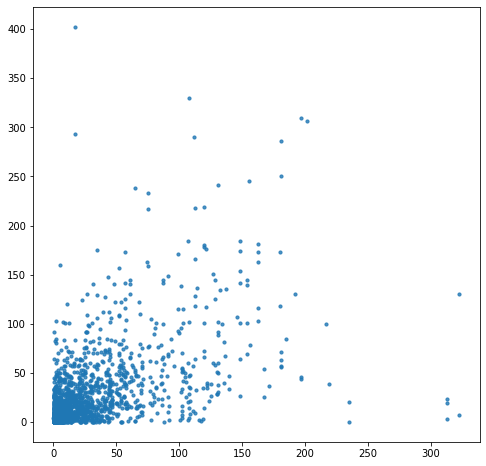

In [32]:
fig, ax = plt.subplots(figsize=(8, 8))
pts = ax.scatter(movies_test_predictions, movies_test_labels, s=10, alpha=0.8)

Looks confusing. I would have expected something a bit more similar to the following plot.

Plotting the same for the training dataset: 

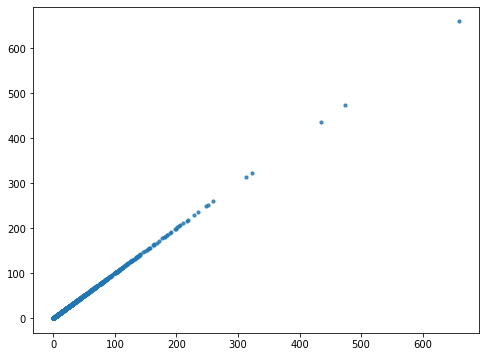

In [33]:
movies_train_prepared =full_pipeline.fit_transform(movies_train)
movies_train_predictions = model.predict(movies_train_prepared)
fig, ax = plt.subplots(figsize=(8, 6))
pts = ax.scatter(movies_train_predictions, movies_train_labels, s=10, alpha=0.8)